### https://www.kaggle.com/competitions/drawing-with-llms

In [2]:
import kagglehub
import pandas as pd

train_path = kagglehub.competition_download('drawing-with-llms', 'train.csv')
train = pd.read_csv(train_path)

train.head()

100%|███████████████████████████████████████████| 759/759 [00:00<00:00, 565kB/s]


,id,description
0,02d892,a purple forest at dusk
1,0dcd2e,gray wool coat with a faux fur collar
2,1e9ac1,a lighthouse overlooking the ocean
3,2b25db,burgundy corduroy pants with patch pockets and...
4,4e6a54,orange corduroy overalls


In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048  # Choose any! We auto support RoPE Scaling internally!
dtype = (
    None  # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
)
load_in_4bit = False # Use 4bit quantization to reduce memory usage. Can be False.

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Meta-Llama-3.1-8B-bnb-4bit",  # Llama-3.1 15 trillion tokens model 2x faster!
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/Meta-Llama-3.1-70B-bnb-4bit",
    "unsloth/Meta-Llama-3.1-405B-bnb-4bit",  # We also uploaded 4bit for 405b!
    "unsloth/Mistral-Nemo-Base-2407-bnb-4bit",  # New Mistral 12b 2x faster!
    "unsloth/Mistral-Nemo-Instruct-2407-bnb-4bit",
    "unsloth/mistral-7b-v0.3-bnb-4bit",  # Mistral v3 2x faster!
    "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    "unsloth/Phi-3.5-mini-instruct",  # Phi-3.5 2x faster!
    "unsloth/Phi-3-medium-4k-instruct",
    "unsloth/gemma-2-9b-bnb-4bit",
    "unsloth/gemma-2-27b-bnb-4bit",  # Gemma 2x faster!
]  # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-1B-Instruct",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.2.15: Fast Llama patching. Transformers: 4.49.0.
   \\   /|    GPU: NVIDIA GeForce RTX 4070 Ti SUPER. Max memory: 15.693 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [4]:
import re
import json
from unsloth.chat_templates import get_chat_template

# Define your tokenizer with a flexible chat template
tokenizer = get_chat_template(
    tokenizer,
    chat_template="chatml",  # Flexible for multiple models (Zephyr, LLaMA, Mistral, etc.)
    mapping={
        "role": "from", 
        "content": "value", 
        "user": "human", 
        "assistant": "gpt"
    },
    map_eos_token=True,  # Ensures <|im_end|> maps to </s> for end-of-sentence
)

# Enable faster inference (2x speed up)
FastLanguageModel.for_inference(model)

def get_svg_code(text):
    """
    This function generates a minimal, valid SVG based on the provided text input.
    """

    # Structured chat template for SVG generation request
    messages = [
        {
            "from": "system", 
            "value": "You are a helpful assistant specialized in generating minimal, valid SVG code"
        },
        {
            "from": "human", 
            "value": f"Now, create an SVG based on the following topic: {text}"
        }
    ]
    
    # Apply the tokenizer and prepare the inputs for the model
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        padding=True,
        truncation=False,
        add_generation_prompt=True,  # Necessary for generation to work
        return_tensors="pt",
    ).to("cuda")
    
    # Create an attention mask to avoid padding interference during inference
    attention_mask = (inputs != tokenizer.pad_token_id).int() 

    # Generate output using the model
    outputs = model.generate(
        input_ids=inputs,
        attention_mask=attention_mask,
        temperature=0.5,  # Low temperature for deterministic results
        max_new_tokens=2048,  # Adjust max tokens if needed
        use_cache=True
    )
    
    # Decode and return the unformatted output (processed into a clean response)
    unformatted_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    return unformatted_output



Unsloth: Will map <|im_end|> to EOS = <|eot_id|>.


In [5]:
train['response']=train['description'].apply(get_svg_code)

In [7]:
import re
from lxml import etree

def clean_svg(svg_string: str) -> str:
    """
    Cleans an SVG string by removing redundant attributes,
    fixing incorrect elements, and ensuring a valid structure.

    Parameters:
    svg_string (str): The input SVG content as a string.

    Returns:
    str: The cleaned SVG content.
    """
    try:
        parser = etree.XMLParser(remove_blank_text=True, remove_comments=True)
        root = etree.fromstring(svg_string, parser=parser)
    except etree.XMLSyntaxError as e:
        print(f"SVG Parse Error: {e}. Returning original SVG.")
        return svg_string

    elements_to_remove = []
    for element in root.iter():
        tag_name = etree.QName(element.tag).localname
        
        # Remove redundant rx attributes
        if tag_name == "rect" and "rx" in element.attrib:
            element.attrib.pop("rx", None)  # Remove duplicate rx attributes
        
        # Remove empty or invalid path elements
        if tag_name == "path":
            d_attr = element.get("d")
            if not d_attr or not re.match(r'^[MmZzLlHhVvCcSsQqTtAa0-9, .-]+$', d_attr):
                elements_to_remove.append(element)
                continue
        
        # Remove unnecessary transform attributes
        if "transform" in element.attrib and "rotate(45" in element.attrib["transform"]:
            element.attrib.pop("transform")
        
    # Remove elements marked for deletion
    for element in elements_to_remove:
        if element.getparent() is not None:
            element.getparent().remove(element)
    
    return etree.tostring(root, encoding="unicode", pretty_print=True)

In [8]:
import re

default_svg = """<svg width="256" height="256" viewBox="0 0 256 256"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""

# Assuming train is a DataFrame with an existing 'svg_code' column
train['svg_code'] = default_svg  # Initialize the 'clean_svg_code' column with the default SVG

# Iterate over the first 15 rows in the 'svg_code' column
for i in range(15):
    # Regex to extract all SVGs from the string in the 'svg_code' column
    svg_matches = re.findall(r'\n(<svg.*?</svg>)\n', train.loc[i, 'response'], re.DOTALL)
    
    # Check if any SVGs were found
    if svg_matches:
        # Update with the last SVG in the matches (if there are multiple)
        train.loc[i, 'svg_code'] = svg_matches[-1]

    else:
        # If no SVG is found, keep the default SVG
        train.loc[i, 'svg_code'] = default_svg



In [9]:
train['svg_clean_code']=train.apply(lambda row: clean_svg(row['svg_code']), axis=1)

0


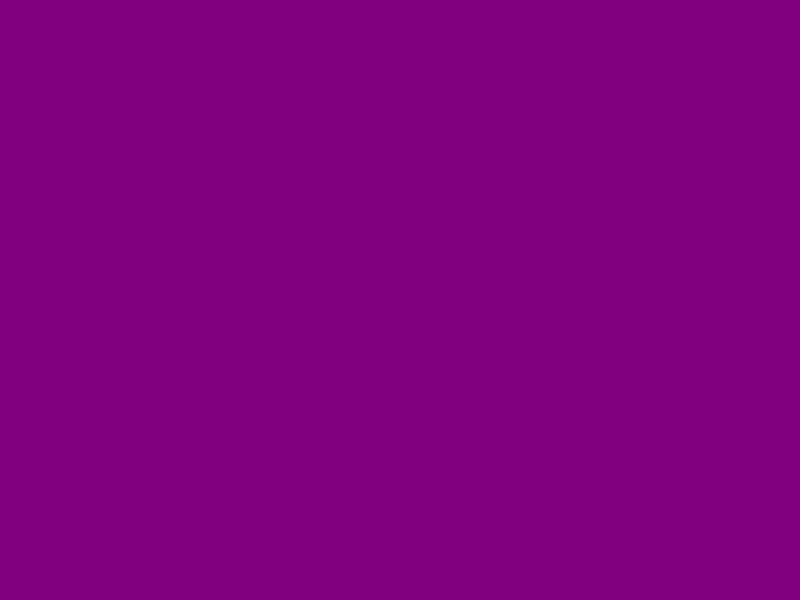

1


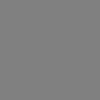

2


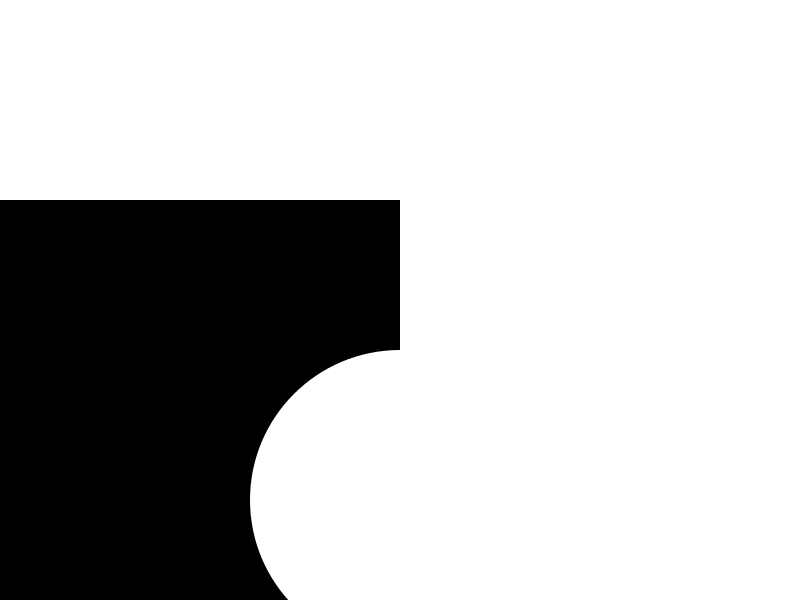

3


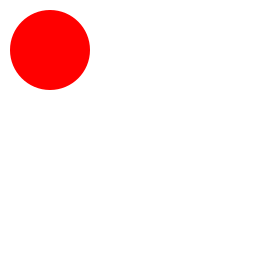

4


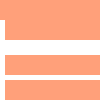

5


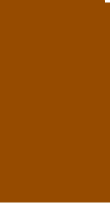

6


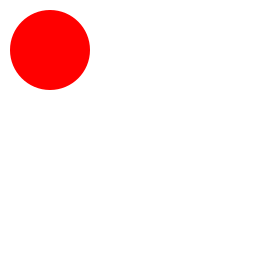

7


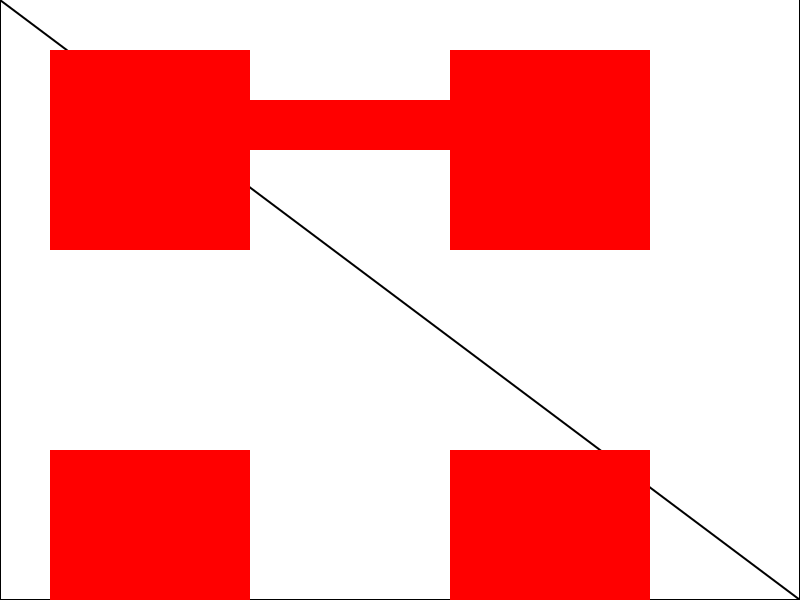

8


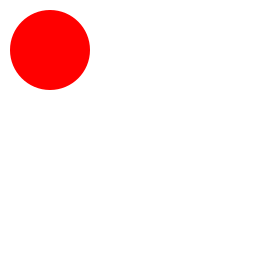

9


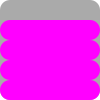

10


11


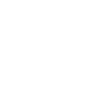

12


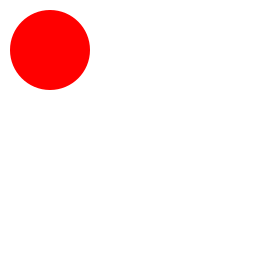

13


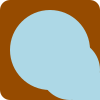

14


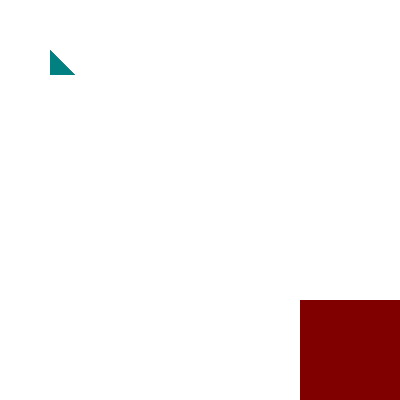

In [11]:
# We can play with our Model and render its SVG output (don't export!)
from IPython.display import SVG, display
for i in range(15):
    print(i)
    display(SVG(train.loc[i,'svg_clean_code']))

In [12]:
from transformers import AutoProcessor, AutoModel
model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

In [13]:
import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor(text=texts, images=image, padding="max_length", return_tensors="pt")
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None




In [15]:
# Using apply to process each row in the DataFrame
train['score'] = train.apply(lambda row: svgMetric(row['description'], row['svg_code']), axis=1)


An error occurred: The SVG size is undefined
An error occurred: The SVG size is undefined


In [16]:
train['score'].mean()

np.float64(0.07907876719978515)